## Results of Host Prediction
### Dataset: BVBRC proteome, Virus Genus Split

**Classification**: Multi-class

**\# classes**: 8

**\# proteins in dataset** = 12,913

**\# train samples** = 6768

**\# validation samples** = 3072

**\# test samples** = 3072

In [2]:
import seaborn

In [3]:
seaborn.__version__

'0.13.2'

In [4]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../..']

In [5]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr
from sklearn.model_selection import train_test_split
from src.utils import utils, evaluation_utils, visualization_utils

In [6]:
def analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col):
    similarity_dfs = []
    n_classes = len(classes)
    for host_rank, filepath in sequence_similarity_filepaths.items():
        similarity_df = pd.read_csv(filepath, index_col=0)
        similarity_df["host_rank"] = host_rank
        similarity_df.rename(columns={label_col: "label"}, inplace=True)
        similarity_dfs.append(similarity_df)
    
    similarity_df = pd.concat(similarity_dfs)
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(n_classes, n_classes, figsize=(36, 36), sharex=True, sharey=True)
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=similarity_df["host_rank"].nunique())
    
    for i, y_test_class in enumerate(classes):
        for j, y_train_class in enumerate(classes):
            ax = axs[i][j]
            sns.kdeplot(data=similarity_df[(similarity_df["label"] == y_test_class) & (similarity_df["target_label"] == y_train_class)], x="similarity_score", hue="host_rank", 
                        palette=color_palette, ax=ax,
                        linewidth=1.5)
            #ax.set_xlabel(f"Similarity w/ {y_train_class}", size=0, labelpad=0)
            ax.set_ylabel(f"{y_test_class}\n\nDensity", size=20)
            ax.set_title(f"Similarity w/\n{y_train_class}", size=20)
            ax.set_xlim(0.0, 1)
            plt.setp(ax.get_legend().get_texts(), fontsize=20)
            ax.get_legend().set_title("")

    return similarity_df

In [7]:
def macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        df.fillna(0, inplace=True)
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 8]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    # sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
    #             palette=color_palette, ax=axs[0],
    #             linewidth=1.5, fliersize=5, linecolor="black", legend=False)

    sns.barplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, legend=False)
    
    #sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    sns.barplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.5, 1), ncol=1, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=20)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    #plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    #plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return auprc_results_df

In [8]:
def macro_and_classwise_auprc_proteome_analysis(output_filepaths, input_filepath, classes, host_rank, label_col, figure_output_filepath=None):
    auprc_results = []
    raw_results = []
    itr_col = "itr"
    y_true_col = "y_true"
    input_df = pd.read_csv(input_filepath)
    for model, output_filepath in output_filepaths.items():
        raw_df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {raw_df.shape}")
        raw_df = raw_df[["protein_id_name", itr_col, y_true_col] + classes].merge(input_df[["proteome_id", "protein", "protein_id_name", label_col, "virus_genus_tax_name"]], on="protein_id_name", how="left")
        raw_df["model"] = model
        raw_results.append(raw_df)
        df = raw_df[classes + ["proteome_id", "y_true", "itr"]]
        df = df.groupby(["proteome_id", "y_true", "itr"]).agg("mean").reset_index()
        df.fillna(0, inplace=True)
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprcs_df["host_rank"] = host_rank
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 8]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    # sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
    #             palette=color_palette, ax=axs[0],
    #             linewidth=1.5, fliersize=5, linecolor="black", legend=False)
    sns.barplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, legend=False)
    
    #sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    sns.barplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.5, 1), ncol=1, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=20)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    #plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    #plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return auprc_results_df

# Host Prediction: Species

In [9]:
input_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_prevalence_gte_onepercent.csv")
classes = ["Human", "Chicken", "Pig", "Domestic cattle", "Norway rat", "Horse", "Wolf", "Boa"]
output_filepaths = {
    "BLAST": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528/host_multi/virus_genus_split/homology/virus_host_species_tax_id_multi_blast_blast_output.csv"),
    "HAVEN": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_adam_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-2_output_itr0.csv"),
}

Read output BLAST = (2402, 14)
Read output HAVEN = (1201, 11)


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


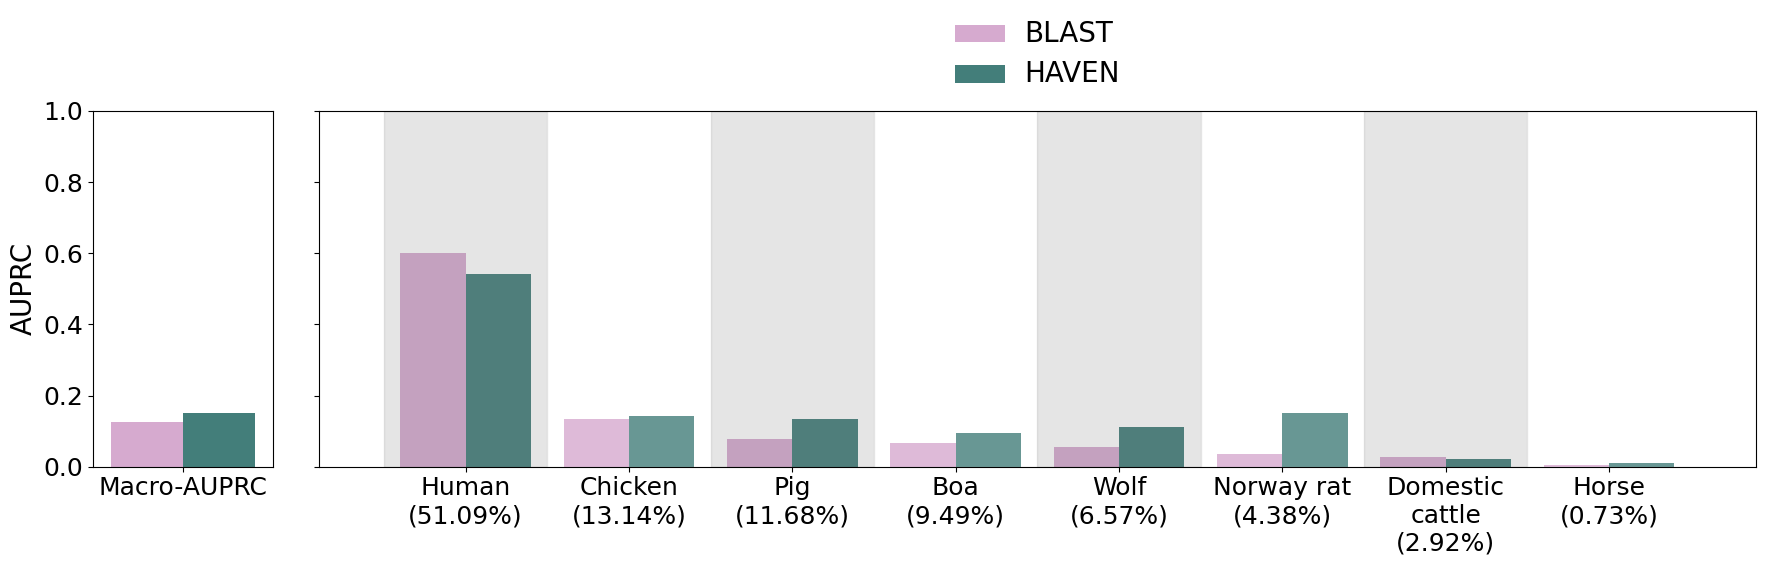

In [10]:
raw_results_df_1 = macro_and_classwise_auprc_proteome_analysis(output_filepaths, input_filepath, classes, host_rank="species", label_col="virus_host_species_tax_id", figure_output_filepath=None)

## Sequence Similarity

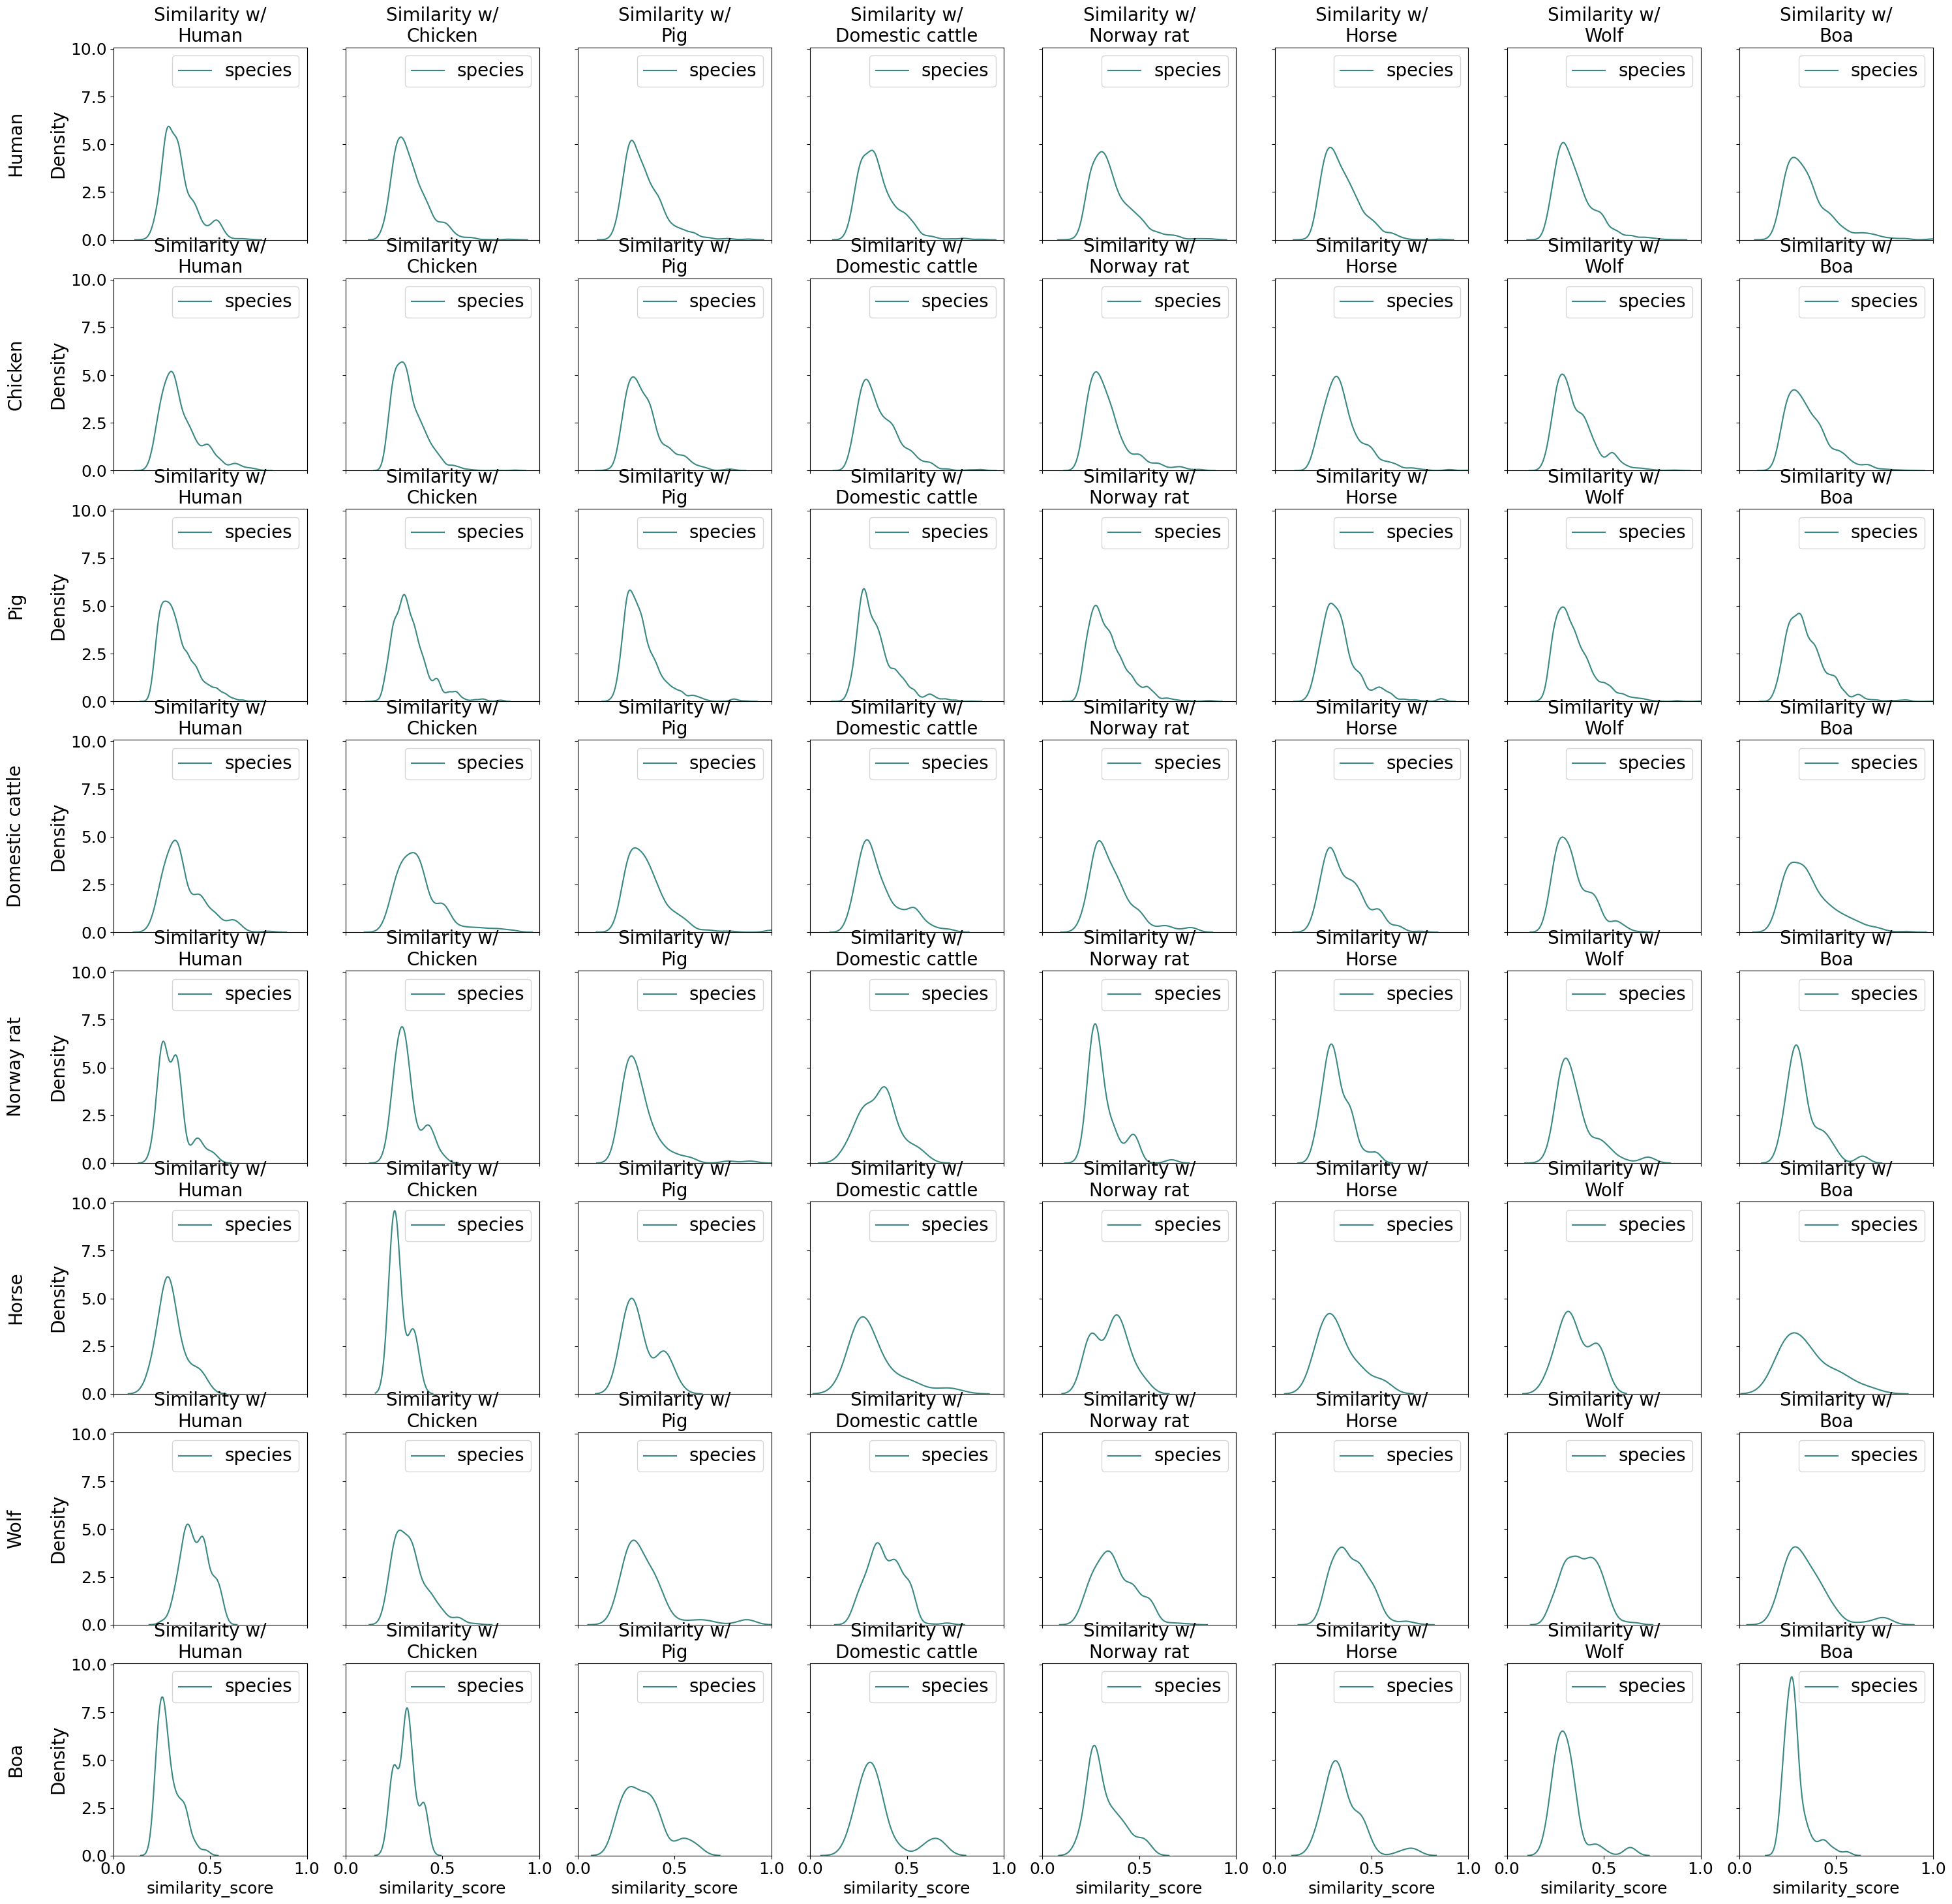

In [11]:
sequence_similarity_filepaths = {
    "species": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528/host_multi/virus_genus_split/homology/virus_host_species_tax_id_multi_blast_blast_similarity_scores.csv"),
}

similarity_df_1 = analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col="virus_host_species_tax_id")

# Host Prediction: Genus

In [12]:
input_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_genus_c8.csv")
classes = ["Homo", "Macaca", "Sus", "Gallus", "Equus", "Bos", "Pteropus", "Rattus"]
output_filepaths = {
    "BLAST": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_genus_vertebrates_c/20260528a/host_multi/virus_genus_split/homology/virus_host_genus_tax_id_multi_blast_blast_output.csv"),
    "HAVEN": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_genus_vertebrates_c8/20260528a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_sgd_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-2_output_itr0.csv"),
}

Read output BLAST = (2708, 14)
Read output HAVEN = (1354, 11)


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


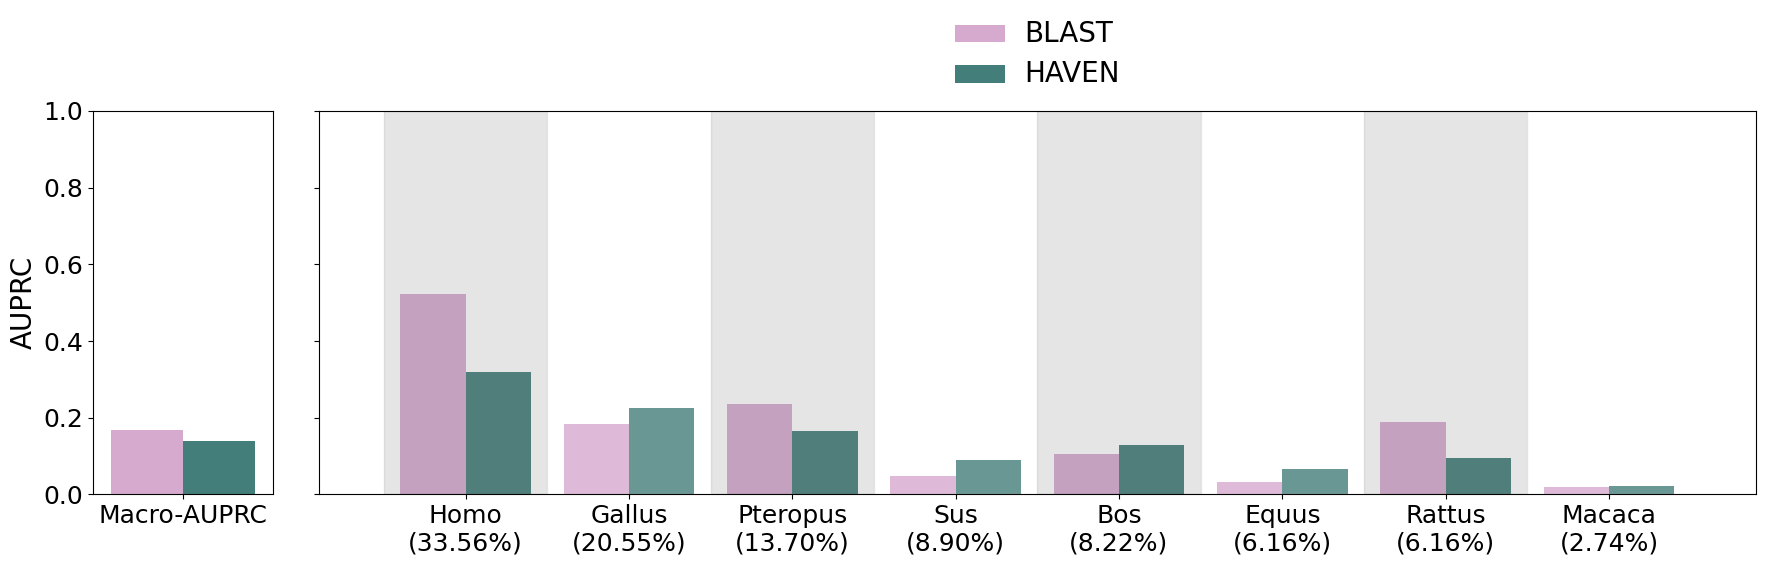

In [13]:
raw_results_df_2 = macro_and_classwise_auprc_proteome_analysis(output_filepaths, input_filepath, classes, host_rank="genus", label_col="virus_host_genus_tax_id", figure_output_filepath=None)

## Sequence Similarity

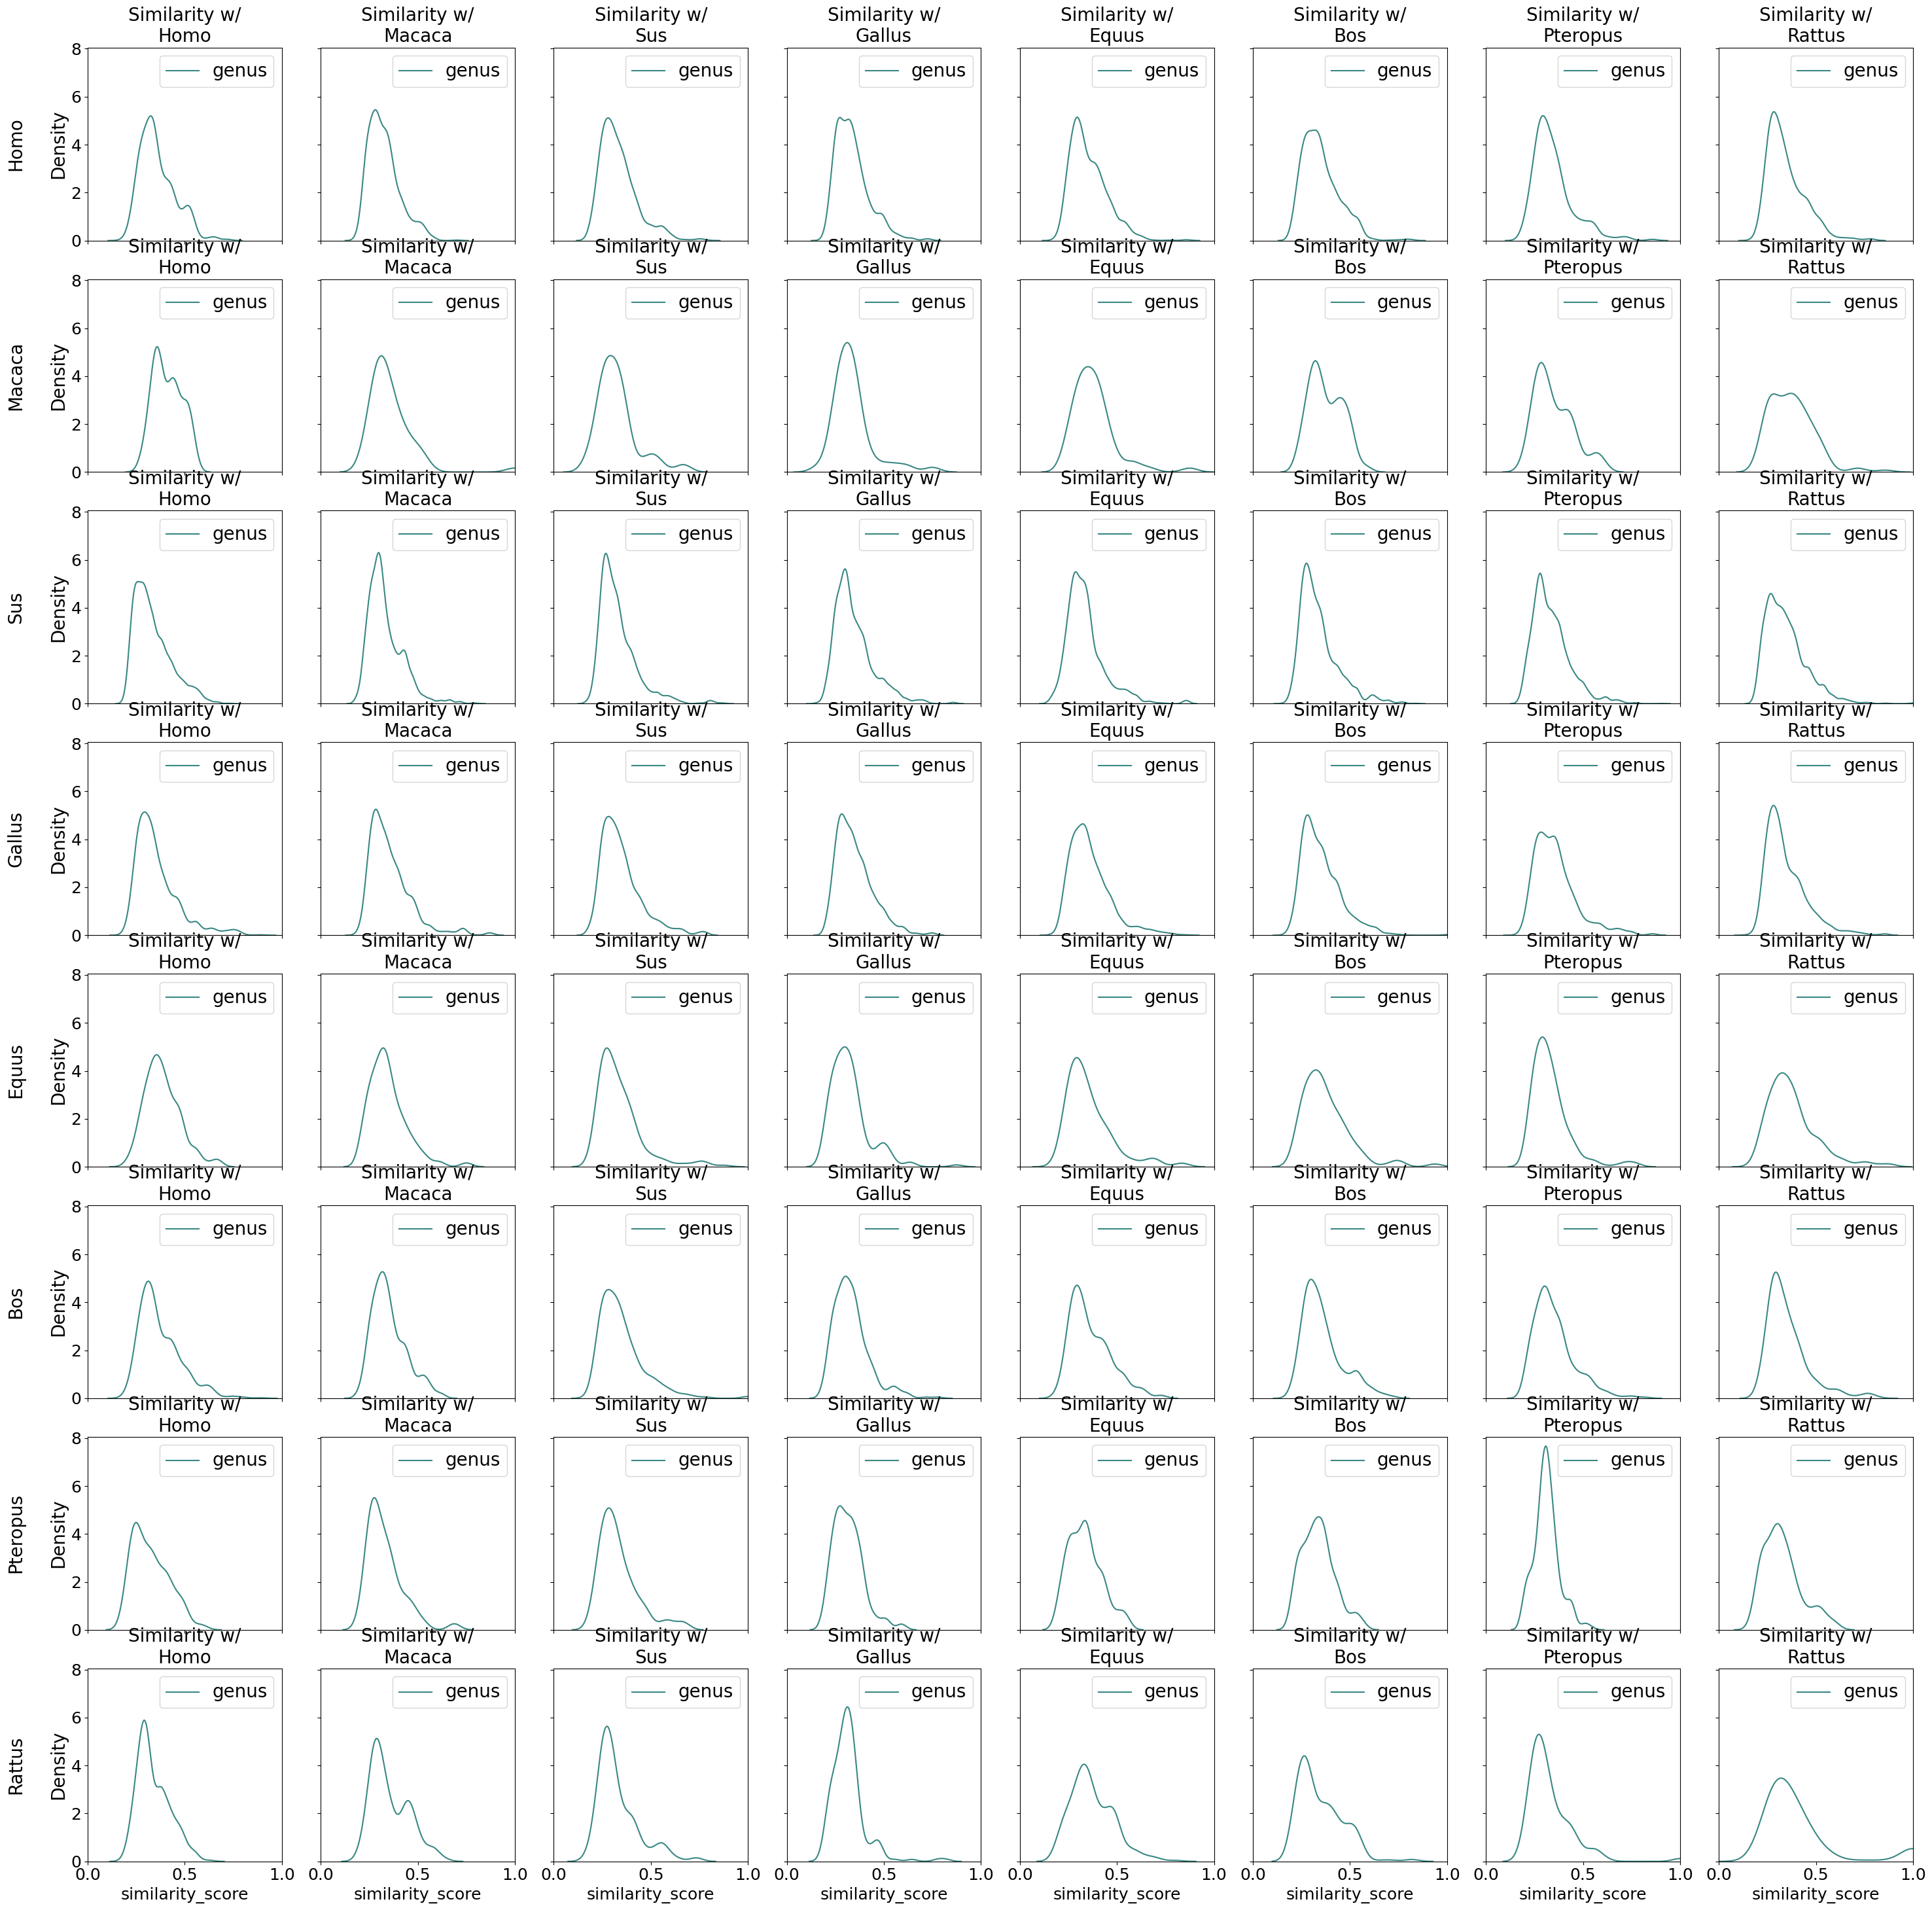

In [14]:
sequence_similarity_filepaths = {
    "genus": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_genus_vertebrates_c/20260528a/host_multi/virus_genus_split/homology/virus_host_genus_tax_id_multi_blast_blast_similarity_scores.csv"),
}

similarity_df_2 = analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col="virus_host_genus_tax_id")

# Host Prediction: Family

In [15]:
input_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_family_c8.csv")
classes = ["Hominidae", "Cercopithecidae", "Suidae", "Bovidae", "Phasianidae", "Muridae", "Cricetidae", "Pteropodidae"]
output_filepaths = {
    "BLAST": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_family_vertebrates_c8/20260528a/host_multi/virus_genus_split/homology/virus_host_family_tax_id_multi_blast_blast_output.csv"),
    "HAVEN": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_family_vertebrates_c8/20260528a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-2_output_itr0.csv"),
}

Read output BLAST = (4550, 14)
Read output HAVEN = (2275, 11)


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


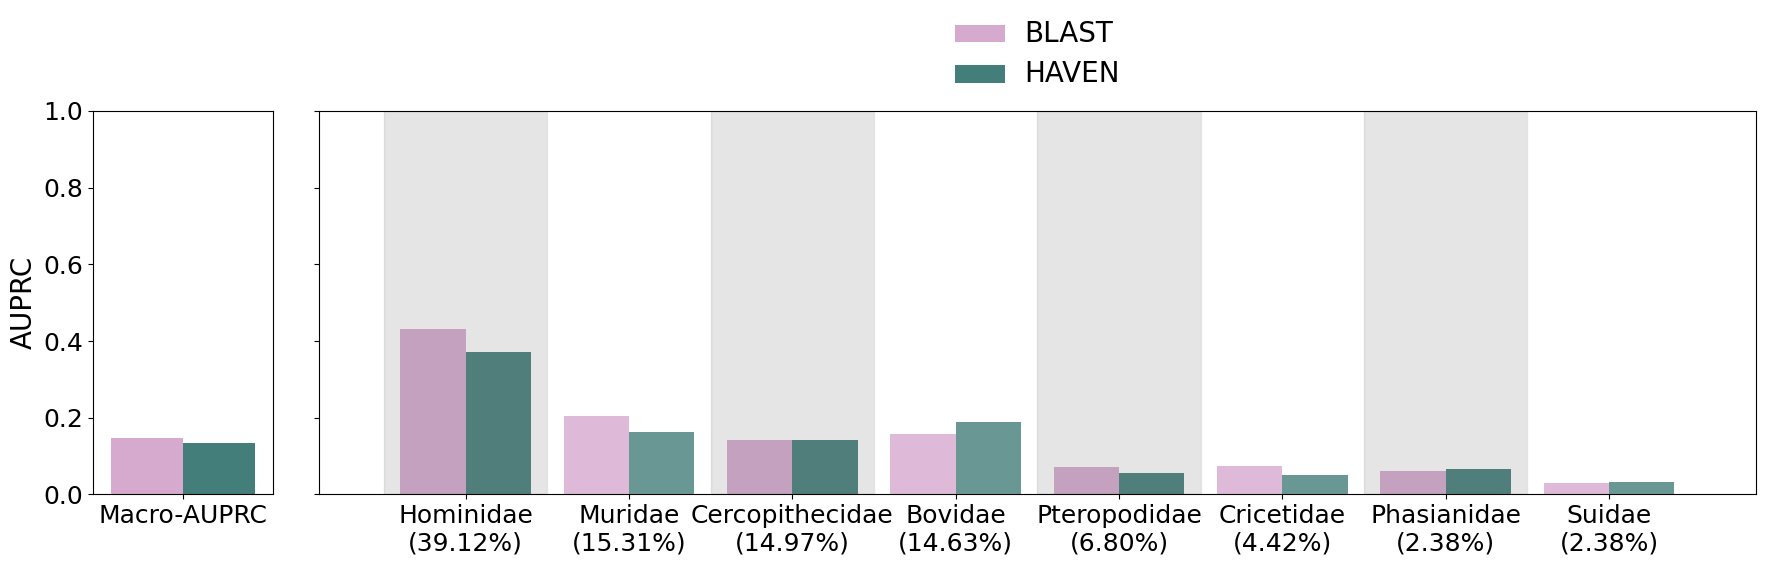

In [16]:
raw_results_df_3 = macro_and_classwise_auprc_proteome_analysis(output_filepaths, input_filepath, classes, host_rank="family", label_col="virus_host_family_tax_id", figure_output_filepath=None)

## Sequence Similarity

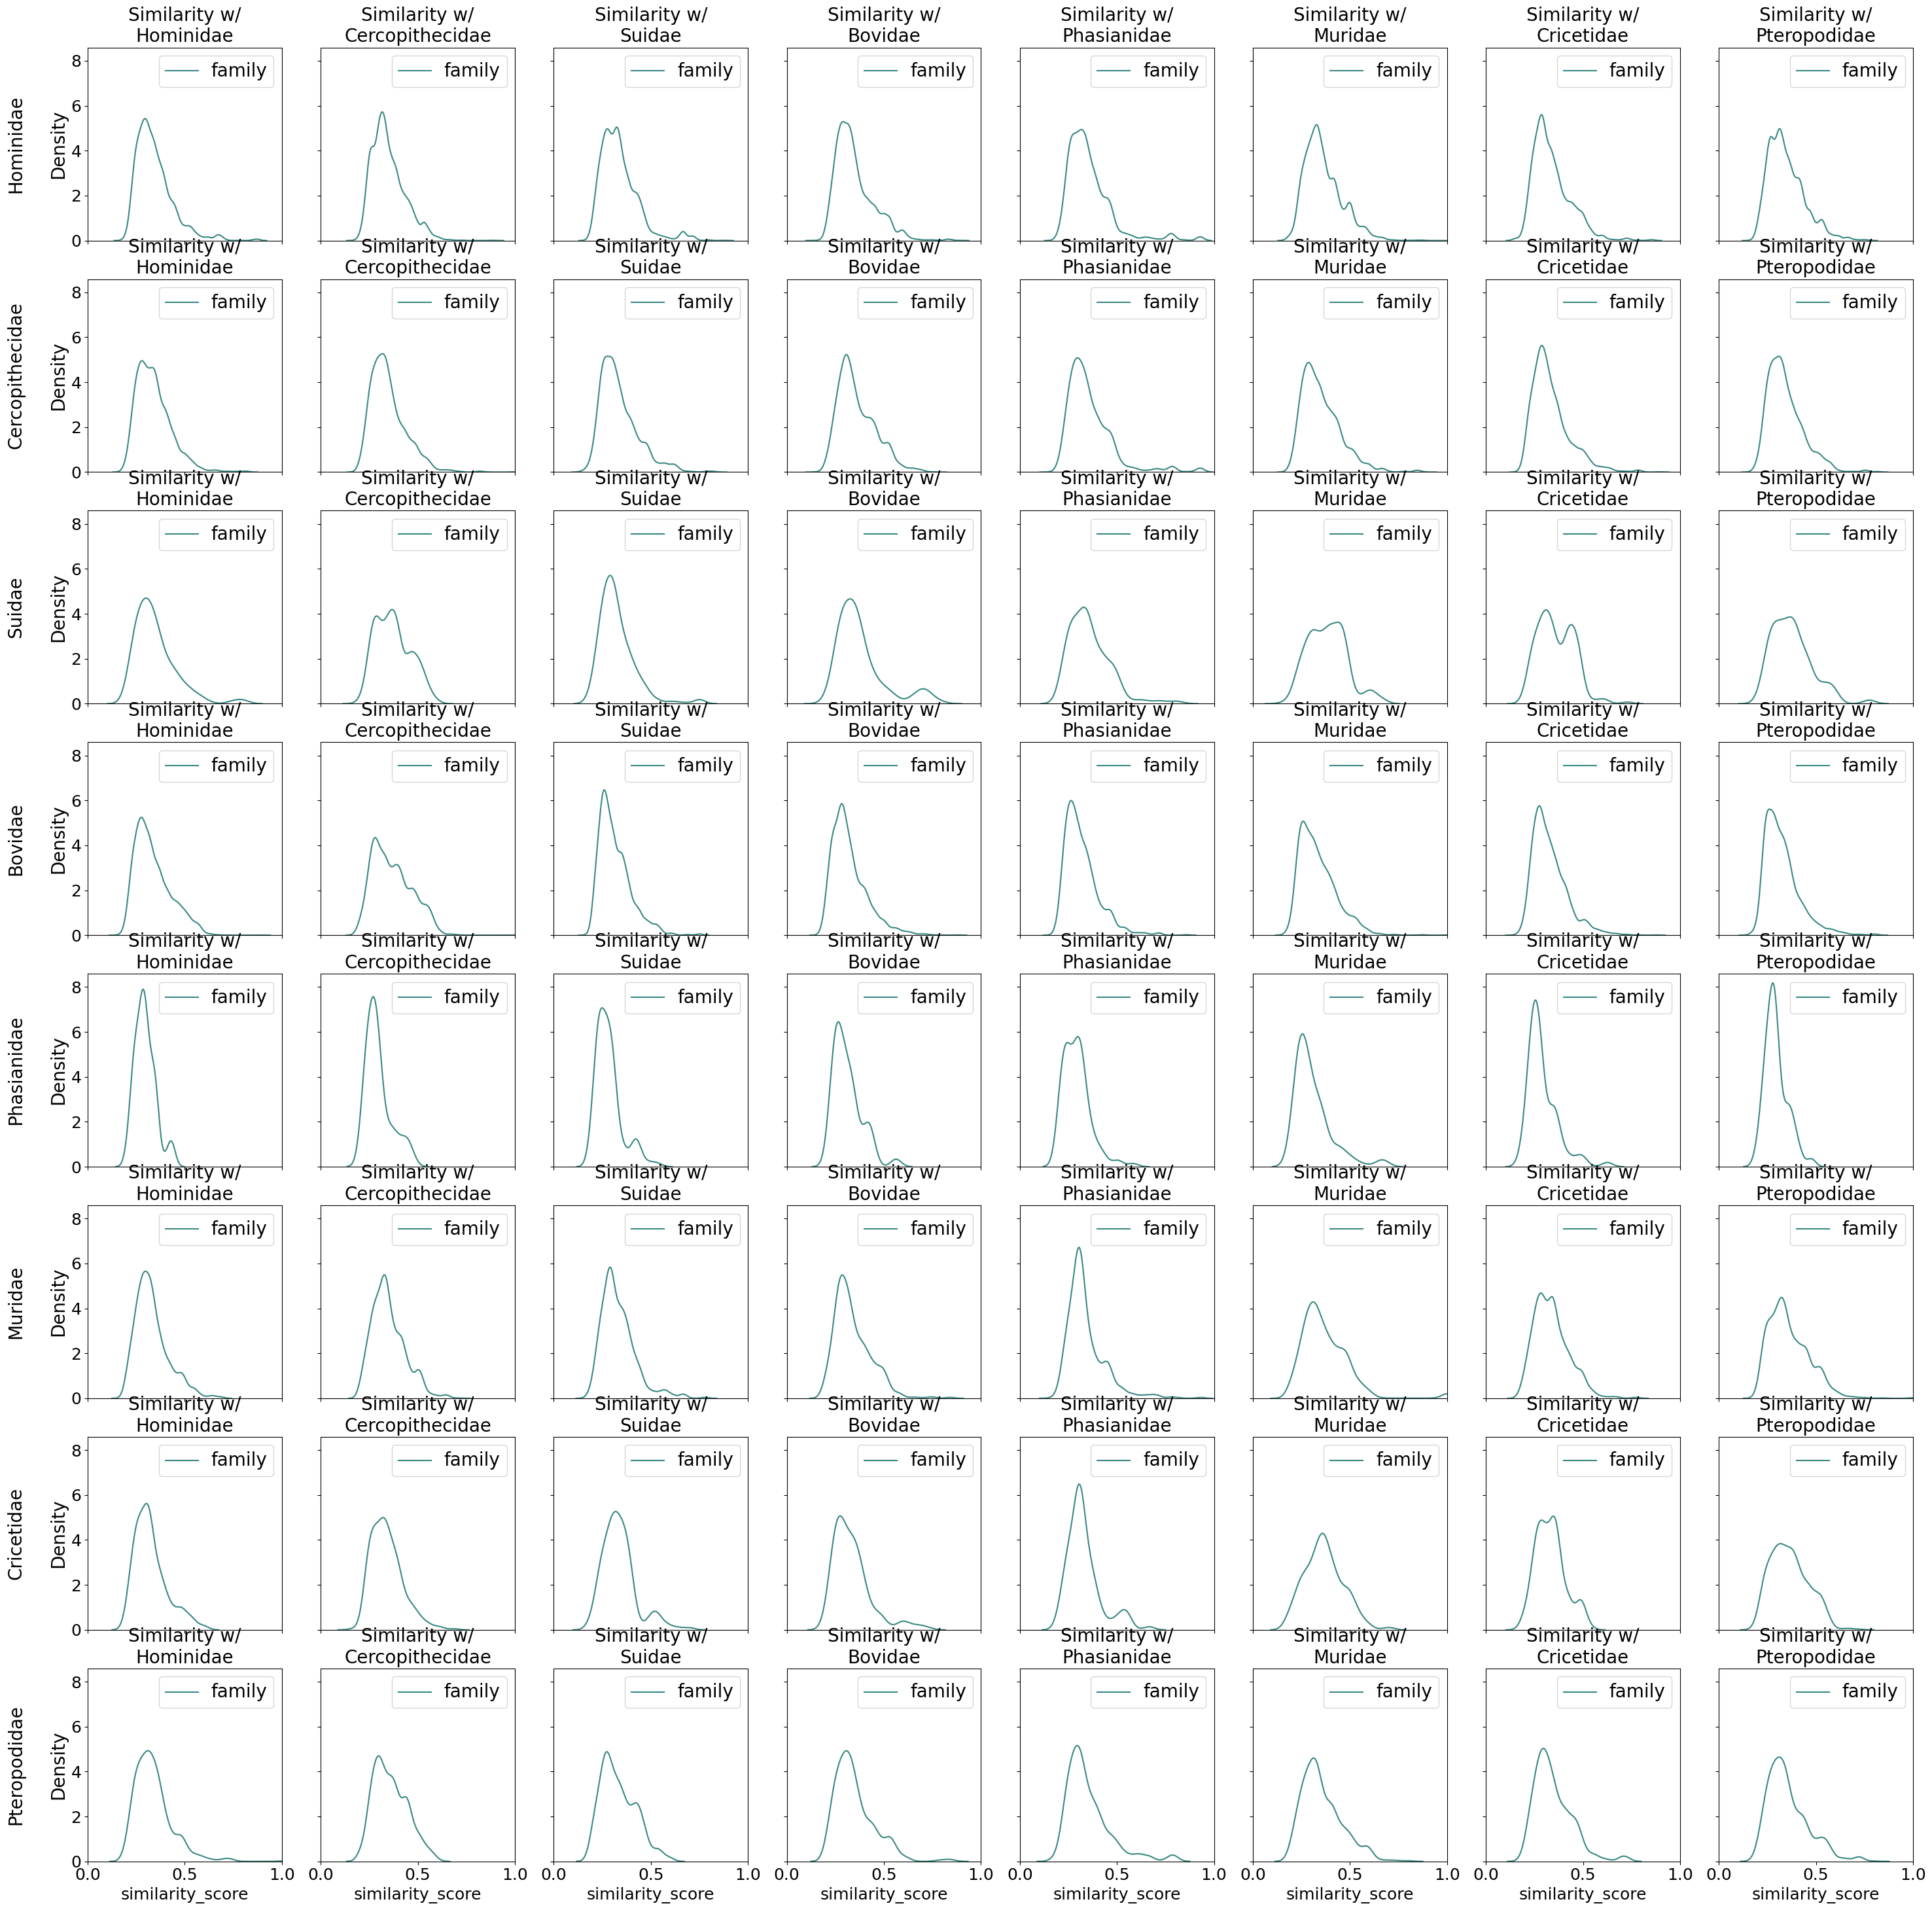

In [17]:
sequence_similarity_filepaths = {
    "family": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_family_vertebrates_c8/20260528a/host_multi/virus_genus_split/homology/virus_host_family_tax_id_multi_blast_blast_similarity_scores.csv"),
}

similarity_df_3 = analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col="virus_host_family_tax_id")

# Host Prediction: Order

In [18]:
input_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_order_c8.csv")
classes = ["Primates", "Artiodactyla", "Chiroptera", "Rodentia", "Carnivora", "Galliformes", "Squamata", "Passeriformes"]
output_filepaths = {
    "BLAST": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_order_vertebrates_c8/20260528a/host_multi/virus_genus_split/homology/virus_host_order_tax_id_multi_blast_blast_output.csv"),
    "HAVEN": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_order_vertebrates_c8/20260528a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-2_output_itr0.csv"),
}

Read output BLAST = (6080, 14)
Read output HAVEN = (3040, 11)


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


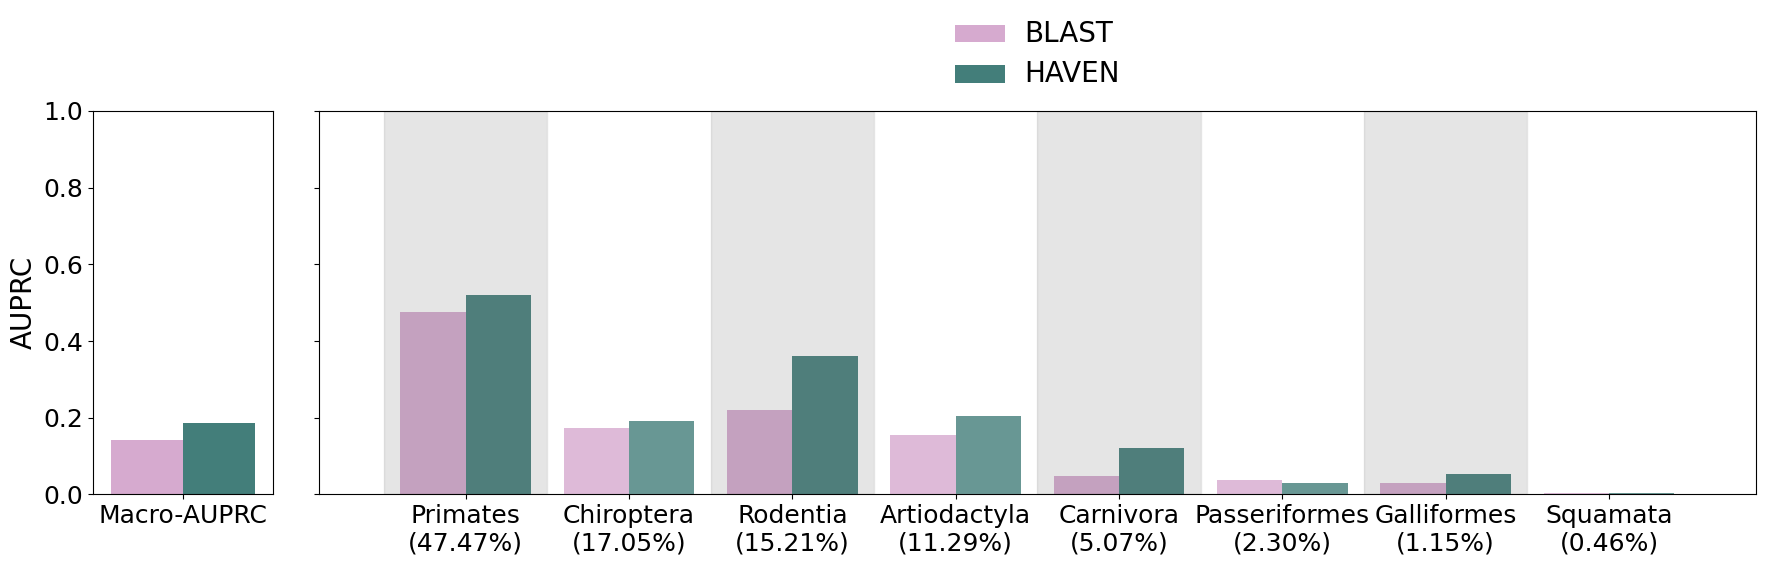

In [19]:
raw_results_df_4 = macro_and_classwise_auprc_proteome_analysis(output_filepaths, input_filepath, classes, host_rank="order", label_col="virus_host_order_tax_id", figure_output_filepath=None)

## Sequence Similarity

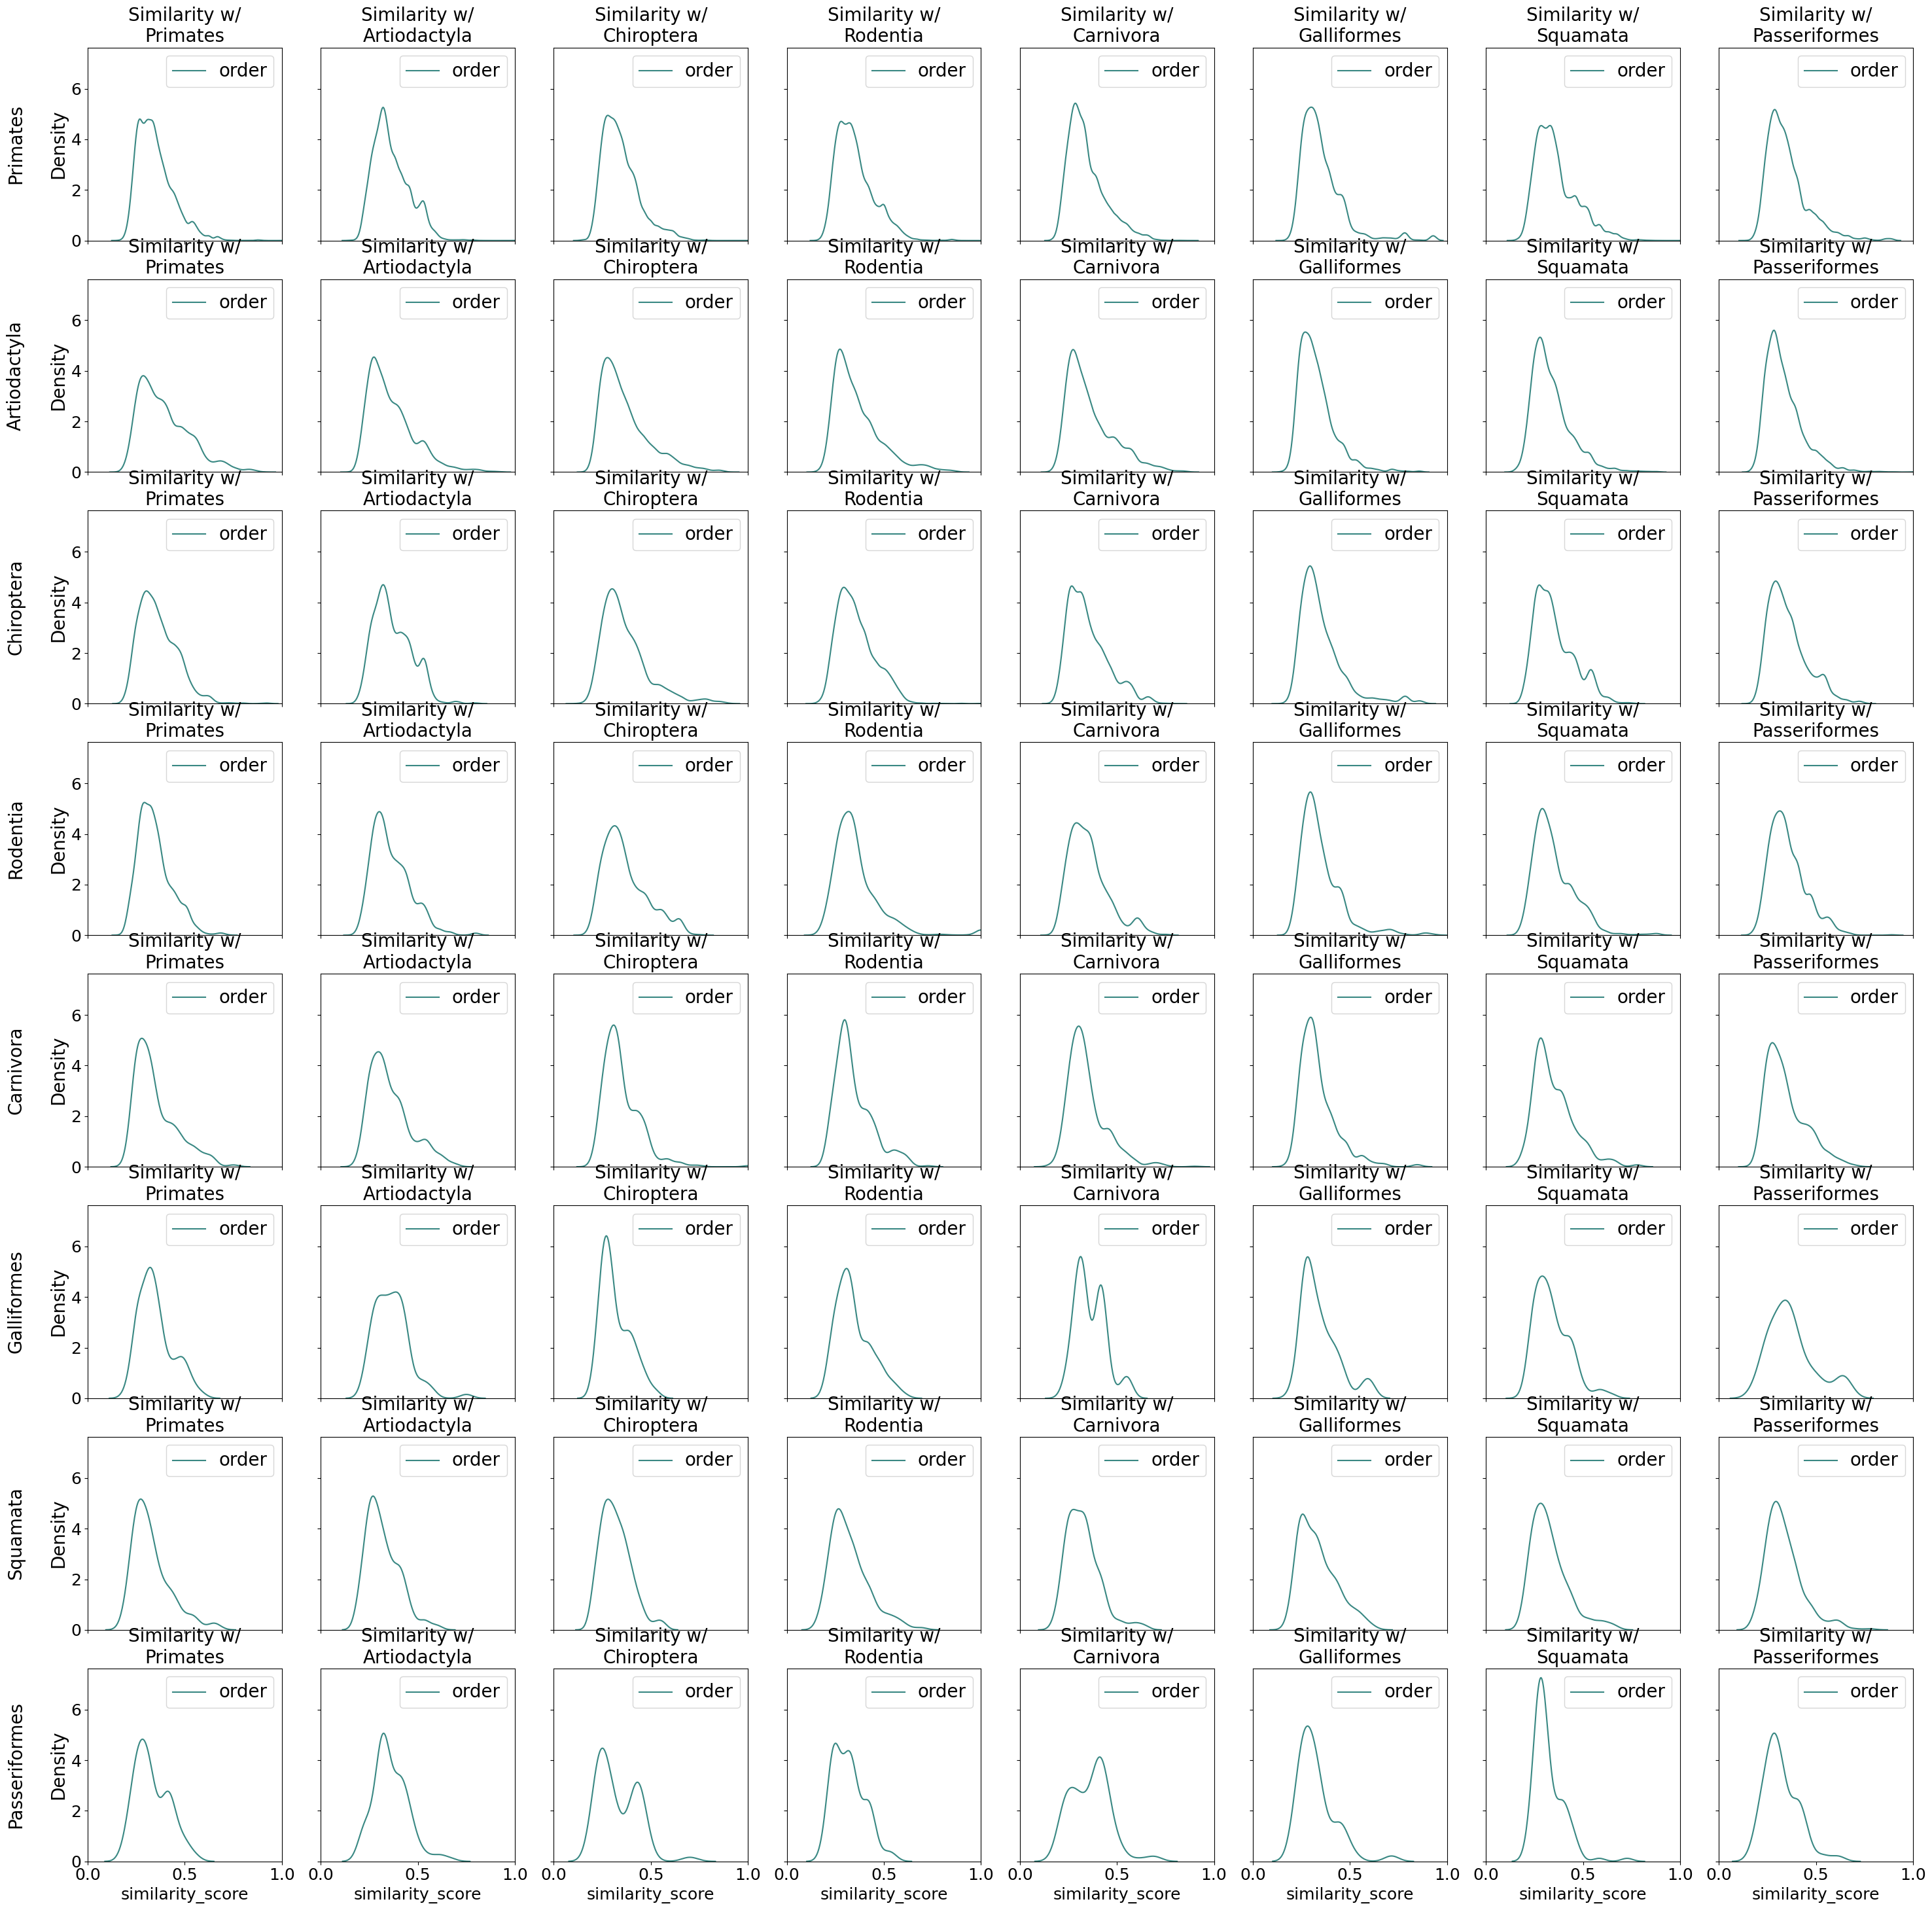

In [20]:
sequence_similarity_filepaths = {
    "order": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_order_vertebrates_c8/20260528a/host_multi/virus_genus_split/homology/virus_host_order_tax_id_multi_blast_blast_similarity_scores.csv"),
}

similarity_df_4 = analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col="virus_host_order_tax_id")

# Overall

In [21]:
raw_results_df = pd.concat([raw_results_df_1, raw_results_df_2, raw_results_df_3, raw_results_df_4])
similarity_df = pd.concat([similarity_df_1, similarity_df_2, similarity_df_3, similarity_df_4])

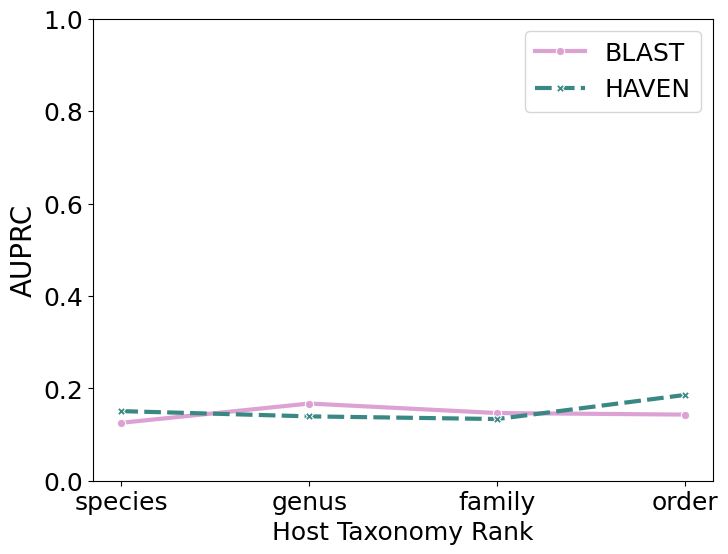

In [27]:
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams.update({'font.size': 18})
fig, axs = plt.subplots(1, 1, figsize=(8, 6), sharex=False, sharey=False)
color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=raw_results_df["model"].nunique())
sns.lineplot(data=raw_results_df[raw_results_df["class"] == "Macro-AUPRC"], x="host_rank", y="auprc", hue="model", 
             linewidth=3, sort=False,
             markers=True, style="model",
             palette=color_palette, ax=axs)
axs.set_ylim(0.0, 1)
axs.set_ylabel("AUPRC", size=20)
axs.set_xlabel("Host Taxonomy Rank", size=18,)
plt.setp(axs.get_legend().get_texts(), fontsize=18)
axs.get_legend().set_title("")
plt.savefig(os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/host-taxonomy-prediction.pdf"), dpi=1024)
plt.show()

/tmp/ipykernel_823454/25746667.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=similarity_df[similarity_df["target_label"] == similarity_df["label"]], x="host_rank", y="similarity_score", linewidth=3, markers=True, style="itr", legend=False, sort=False, palette=color_palette, ax=axs)


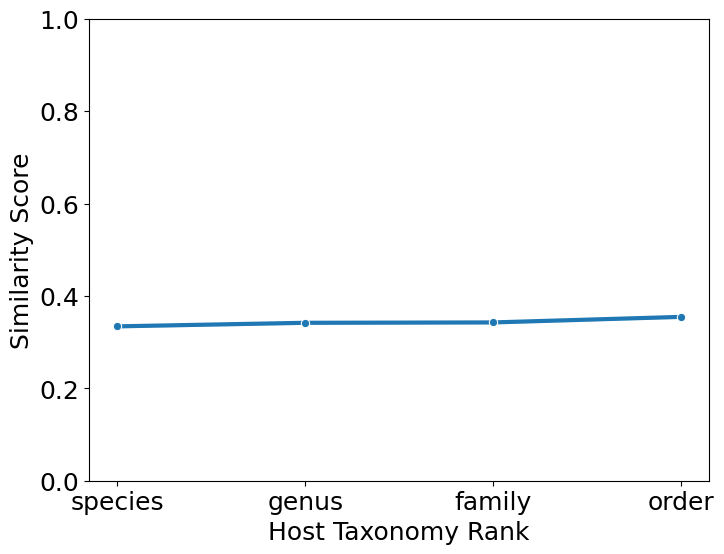

In [23]:
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams.update({'font.size': 18})
fig, axs = plt.subplots(1, 1, figsize=(8, 6), sharex=False, sharey=False)
color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=raw_results_df["model"].nunique())
sns.lineplot(data=similarity_df[similarity_df["target_label"] == similarity_df["label"]], x="host_rank", y="similarity_score", linewidth=3, markers=True, style="itr", legend=False, sort=False, palette=color_palette, ax=axs)
axs.set_ylim(0.0, 1)
axs.set_ylabel("Similarity Score", size=18)
axs.set_xlabel("Host Taxonomy Rank", size=18,)
plt.show()

In [80]:
similarity_df

,protein_id_name,target_seq_id,similarity_score,target_label,label,itr,host_rank
0,AJZ77038.1_CP2475L,9394,0.19883,Human,Pig,0,species
1,AJZ77038.1_CP2475L,6691,0.19298,Human,Pig,0,species
2,AJZ77038.1_CP2475L,5722,0.23301,Human,Pig,0,species
3,AJZ77038.1_CP2475L,9387,0.19883,Human,Pig,0,species
4,AJZ77038.1_CP2475L,9470,0.34286,Human,Pig,0,species
...,...,...,...,...,...,...,...
29013,ADZ39830.1_E4-orf1,13103,0.21649,Passeriformes,Primates,0,order
29014,ADZ39830.1_E4-orf1,22988,0.42857,Passeriformes,Primates,0,order
29015,ADZ39830.1_E4-orf1,13100,0.39130,Passeriformes,Primates,0,order
29016,ADZ39830.1_E4-orf1,22960,0.30435,Passeriformes,Primates,0,order
